# Vibration Prediction System - Example Usage

This notebook demonstrates how to use the vibration prediction system for training and evaluating LSTM models on vibration data.

## 1. Setup and Imports

In [2]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import yaml
from pathlib import Path

# Add project to path
project_root = Path.cwd()
sys.path.append(str(project_root))

# Import project modules
from data.dataset import VibrationDataset, create_dataloaders
from models.lstm_predictor import LSTMPredictor
from training.trainer import Trainer
from utils.visualization import VibrationVisualizer
from utils.signal_processing import compute_spectral_features, detect_bifurcation_points

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Setup complete!")

Setup complete!


## 2. Load Configuration

In [3]:
# Load configuration files
with open('config/base_config.yaml', 'r') as f:
    base_config = yaml.safe_load(f)

with open('config/lstm_config.yaml', 'r') as f:
    lstm_config = yaml.safe_load(f)

# Merge configurations
config = base_config.copy()
for key, value in lstm_config.items():
    if key in config and isinstance(config[key], dict) and isinstance(value, dict):
        config[key].update(value)
    else:
        config[key] = value

print("Configuration loaded:")
print(f"- Window size: {config['data']['window_size']}")
print(f"- Prediction horizon: {config['data']['prediction_horizon']}")
print(f"- Model type: {config['model']['type']}")
print(f"- Hidden size: {config['model']['hidden_size']}")

Configuration loaded:
- Window size: 1000
- Prediction horizon: 200
- Model type: lstm
- Hidden size: 256


In [4]:
config

{'data': {'window_size': 1000,
  'prediction_horizon': 200,
  'stride': 100,
  'sampling_rate': 10,
  'train_split': 0.7,
  'val_split': 0.15,
  'test_split': 0.15,
  'dataset_path': 'project/create_datasets/datasets',
  'dataset_name': 'mathieu_delayed_dataset.pkl'},
 'features': {'use_features': ['basic'], 'window_sizes': [10, 50, 100]},
 'training': {'batch_size': 64,
  'learning_rate': 0.0005,
  'epochs': 100,
  'early_stopping_patience': 15,
  'gradient_clipping': 1.0,
  'optimizer': 'adam',
  'scheduler': 'reduce_lr_on_plateau',
  'weight_decay': '1e-5',
  'scheduler_patience': 10,
  'scheduler_factor': 0.5},
 'augmentation': {'noise_level': 0.01,
  'time_warping': True,
  'parameter_interpolation': True,
  'enabled': False},
 'model': {'hidden_size': 256,
  'num_layers': 2,
  'dropout': 0.3,
  'recurrent_dropout': 0.3,
  'type': 'lstm',
  'bidirectional': False,
  'input_normalization': 'z_score',
  'output_layers': [128, 64],
  'output_activation': 'tanh'},
 'loss': {'weights':

## 3. Load and Explore Dataset

In [5]:
# Create dataset
dataset_config = {
    'data_path': 'create_datasets/datasets/mathieu_delayed_dataset_shrink.pkl',
    'window_size': config['data']['window_size'],
    'prediction_horizon': config['data']['prediction_horizon'],
    'stride': config['data']['stride'],
    'train_split': config['data']['train_split'],
    'val_split': config['data']['val_split'],
    'test_split': config['data']['test_split'],
    'sampling_rate': config['data']['sampling_rate'],
    'features': config['features']['use_features'],
    'random_seed': config['random_seed']
}

dataset_config["sampling_rate"] = 4
dataset_config["stride"] = dataset_config["window_size"]

print(json.dumps(dataset_config, indent=2))
# Create train dataset to explore
train_dataset = VibrationDataset(split='train', **dataset_config)

print(f"Dataset loaded:")
print(f"- Total sequences: {len(train_dataset)}")
print(f"- Feature names: {train_dataset.features}")

# Get a sample
sample = train_dataset[0]
print(f"\nSample shapes:")
print(f"- Features: {sample['features'].shape}")
# print(f"- Parameters: {sample['parameters'].shape}")
print(f"- Targets: {sample['targets'].shape}")
# print(f"- Max amplitude: {sample['max_amplitude'].item():.4f}")

{
  "data_path": "create_datasets/datasets/mathieu_delayed_dataset_shrink.pkl",
  "window_size": 1000,
  "prediction_horizon": 200,
  "stride": 1000,
  "train_split": 0.7,
  "val_split": 0.15,
  "test_split": 0.15,
  "sampling_rate": 4,
  "features": [
    "basic"
  ],
  "random_seed": 42
}
Dataset loaded:
- Total sequences: 26581
- Feature names: ['basic']

Sample shapes:
- Features: torch.Size([1000, 2])
- Targets: torch.Size([200, 2])


In [6]:
train_dataset.scalers

{'x': StandardScaler(), 'x_dot': StandardScaler(), 'params': StandardScaler()}

## 4. Visualize Sample Data

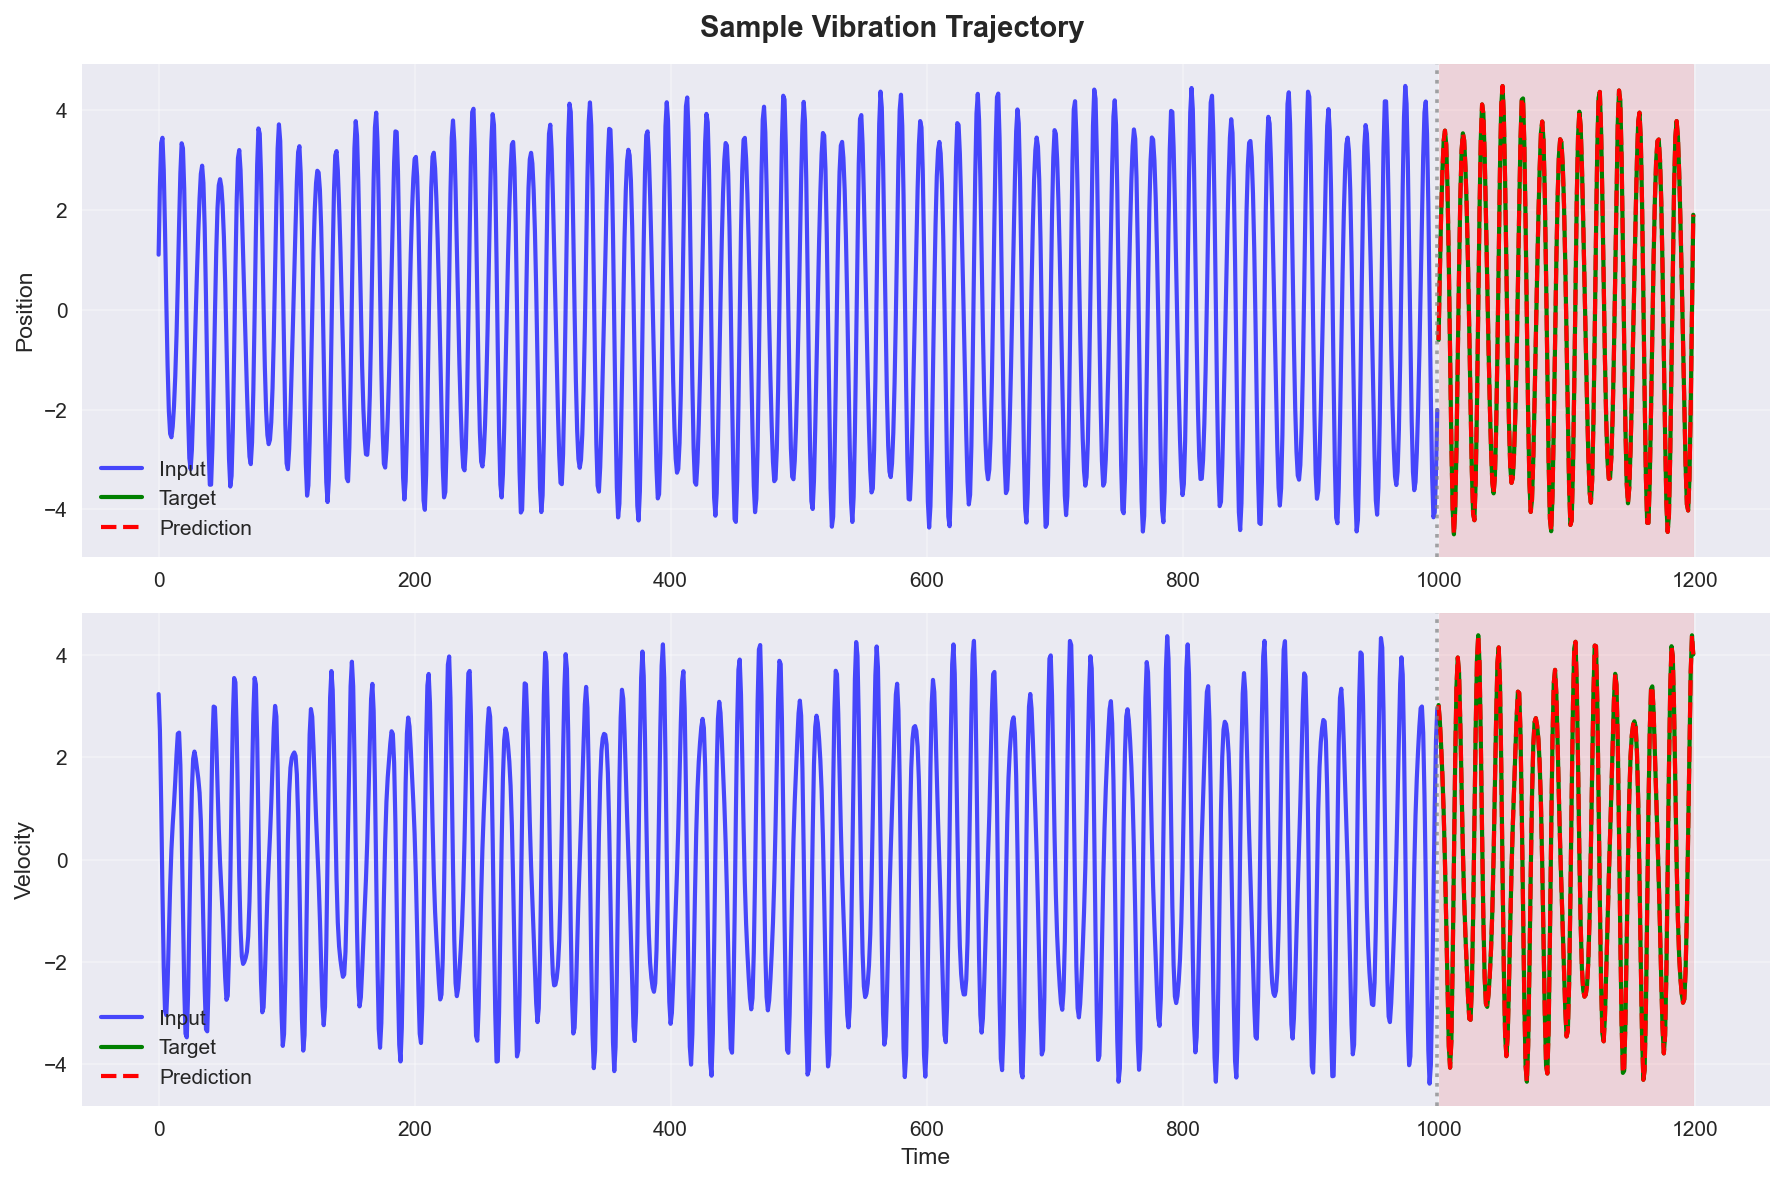

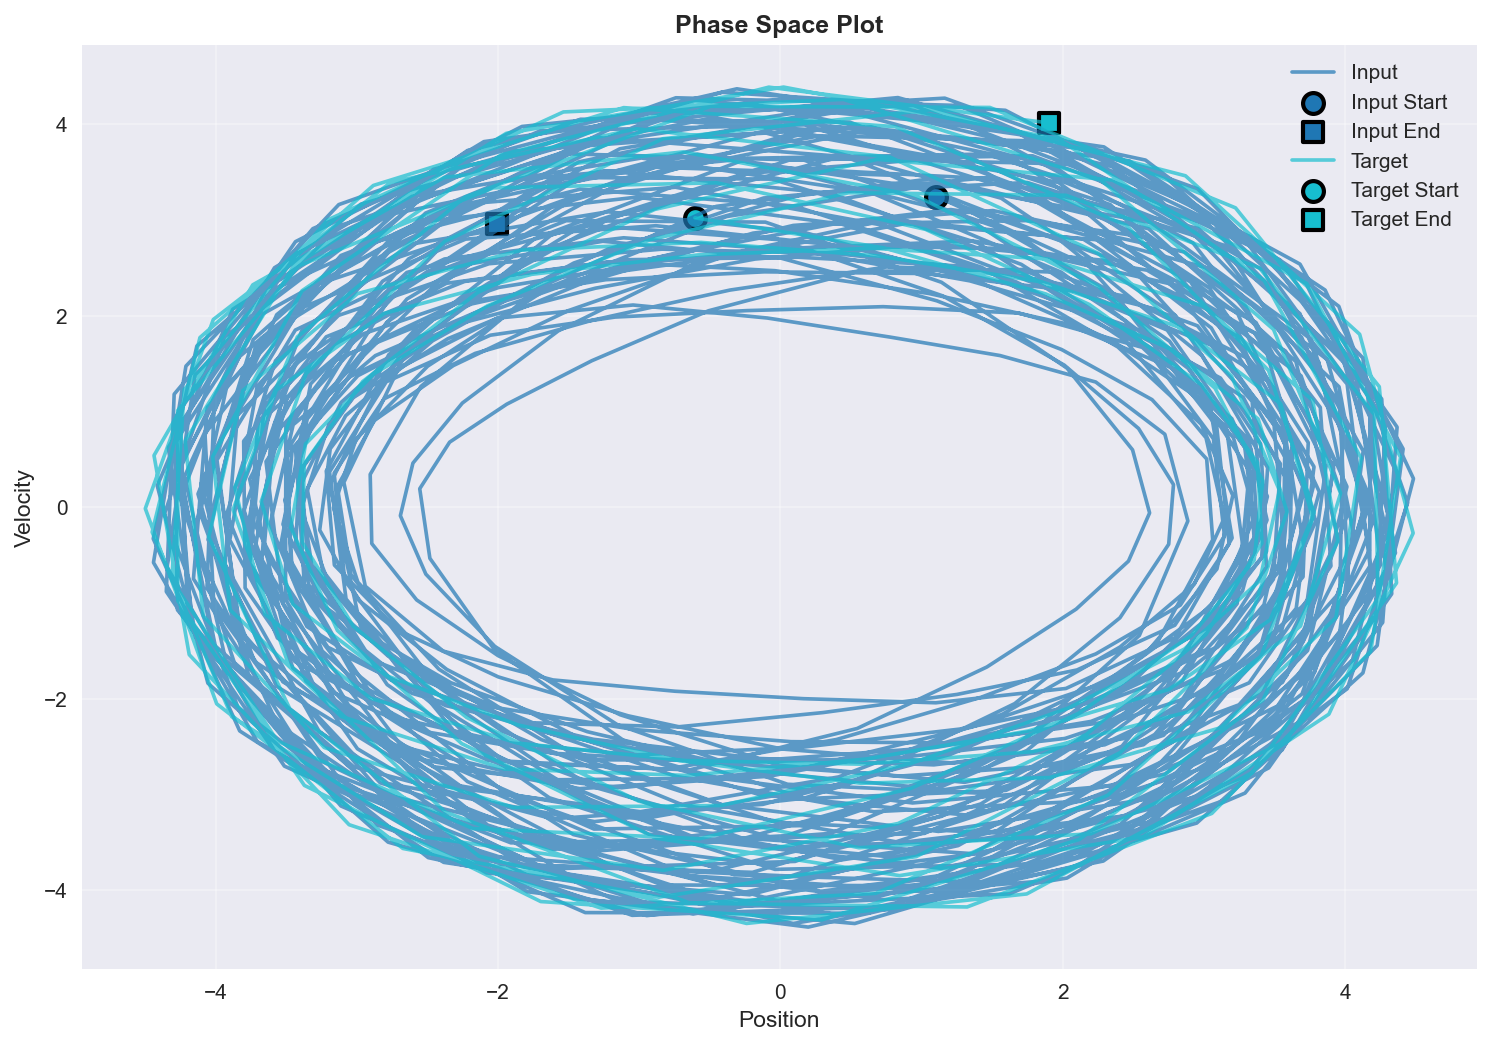

In [7]:
# Create visualizer
visualizer = VibrationVisualizer()

# Get sample data
sample = train_dataset[240]
features = sample['features'].numpy()
targets = sample['targets'].numpy()

# Plot trajectory comparison (using features as input, targets as ground truth)
fig = visualizer.plot_trajectory_comparison(
    input_data=features,
    target_data=targets,
    predicted_data=targets,  # Using targets as "prediction" for visualization
    feature_names=['Position', 'Velocity'],
    title='Sample Vibration Trajectory'
)
plt.show()

# Plot phase space
fig = visualizer.plot_phase_space(
    trajectories=[features, targets],
    labels=['Input', 'Target'],
    title='Phase Space Plot'
)
plt.show()

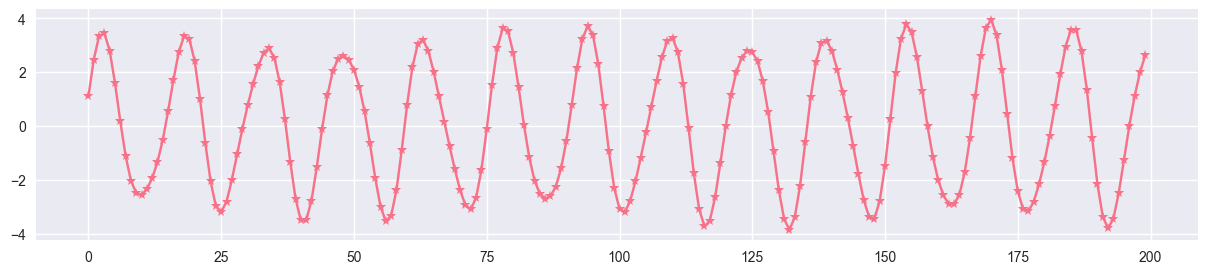

In [8]:
plt.figure(figsize=(15, 3))
plt.plot(np.arange(len(features[:200, 0])), features[:200, 0], "-*")

## 5. Analyze Signal Properties

Spectral Features:
- Dominant frequency: 0.66 Hz
- Spectral centroid: 0.67 Hz
- Spectral spread: 0.08 Hz
- Total power: 182.0739

Bifurcation Analysis:
- Number of bifurcation points: 0


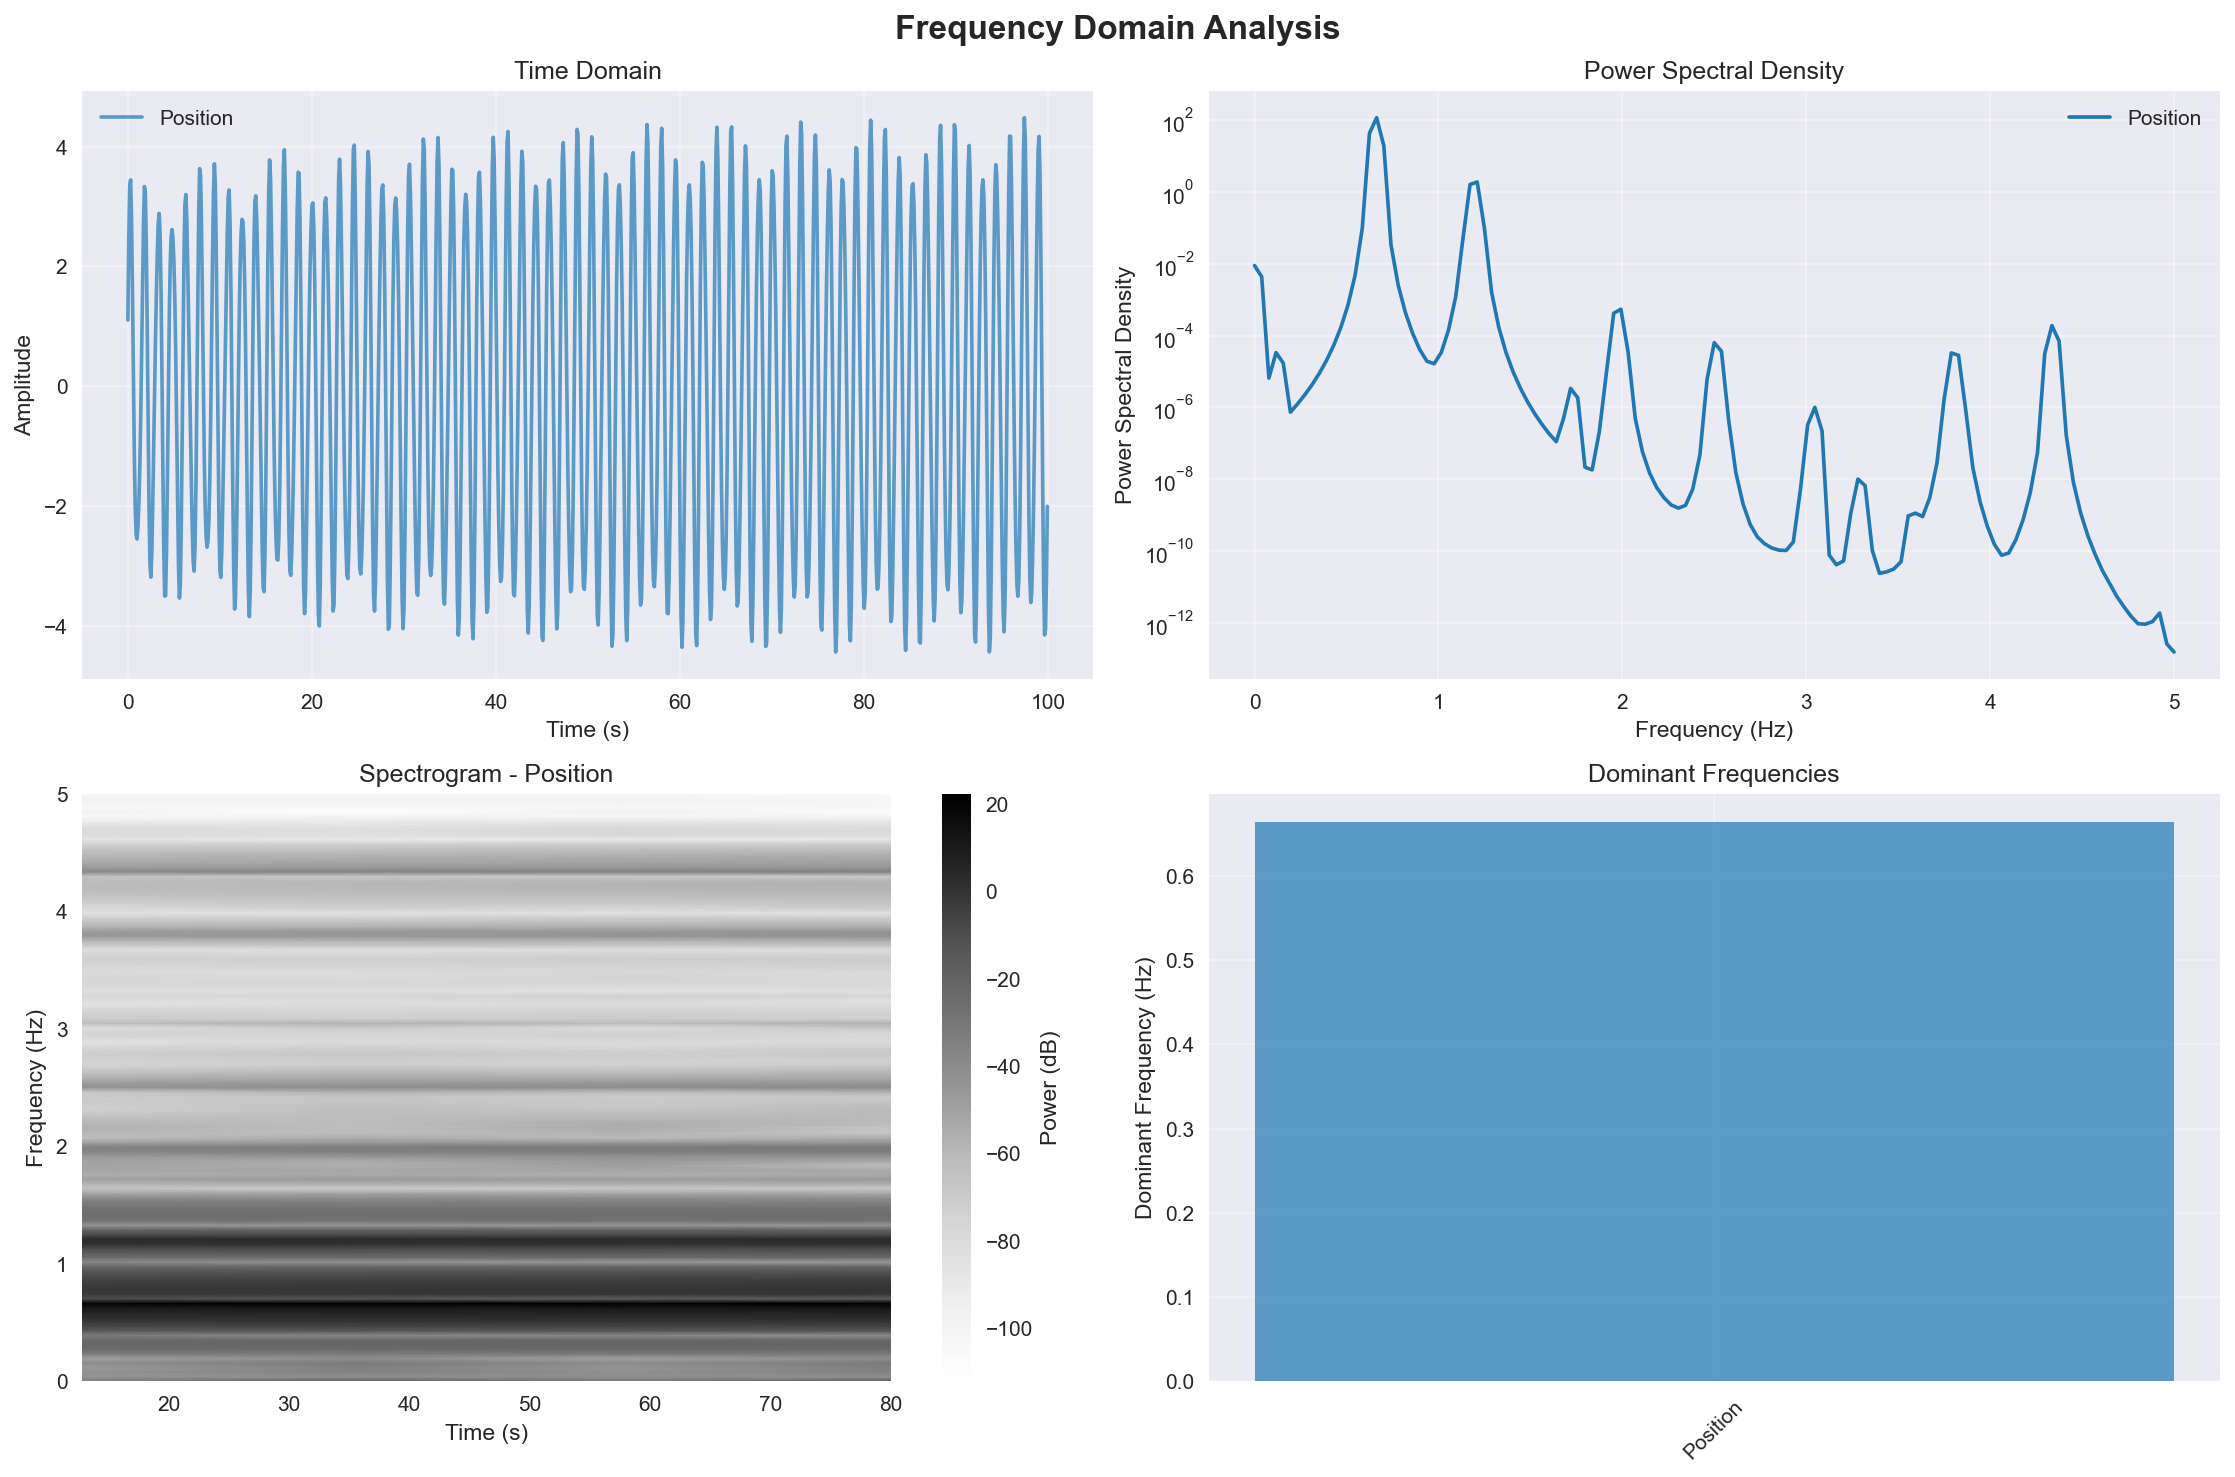

In [9]:
# Analyze spectral properties
position_signal = features[:, 0]
spectral_features = compute_spectral_features(position_signal, fs=config['data']['sampling_rate'])

print("Spectral Features:")
print(f"- Dominant frequency: {spectral_features['dominant_frequency']:.2f} Hz")
print(f"- Spectral centroid: {spectral_features['spectral_centroid']:.2f} Hz")
print(f"- Spectral spread: {spectral_features['spectral_spread']:.2f} Hz")
print(f"- Total power: {spectral_features['total_power']:.4f}")

# Detect bifurcation points
bifurcation_points, bifurcation_amplitudes = detect_bifurcation_points(position_signal)
print(f"\nBifurcation Analysis:")
print(f"- Number of bifurcation points: {len(bifurcation_points)}")
if len(bifurcation_points) > 0:
    print(f"- Max bifurcation amplitude: {np.max(bifurcation_amplitudes):.4f}")

# Plot frequency analysis
fig = visualizer.plot_frequency_analysis(
    signals=[position_signal],
    labels=['Position'],
    sampling_rate=config['data']['sampling_rate'],
    title='Frequency Domain Analysis'
)
plt.show()

## 6. Create Data Loaders

In [10]:
# Create data loaders
train_loader, val_loader, test_loader = create_dataloaders(
    dataset_config,
    batch_size=config['training']['batch_size'],
    num_workers=2  # Reduce for notebook
)

print(f"Data loaders created:")
print(f"- Train batches: {len(train_loader)}")
print(f"- Validation batches: {len(val_loader)}")
print(f"- Test batches: {len(test_loader)}")

# Check a batch
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
for key, value in batch.items():
    if isinstance(value, torch.Tensor):
        print(f"- {key}: {value.shape}")
    else:
        print(f"- {key}: {type(value)}")

Data loaders created:
- Train batches: 416
- Validation batches: 90
- Test batches: 90


/Users/adosyuk/miniconda3/envs/env/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Batch shapes:
- features: torch.Size([64, 1000, 2])
- targets: torch.Size([64, 200, 2])


## 7. Create and Initialize Model

In [28]:
# Setup model configuration
model_config = config['model'].copy()
model_config['input_size'] = 2  # x, x_dot
model_config['output_size'] = 1  # x
# model_config['n_params'] = 15  # Number of system parameters

# Create model
model = LSTMPredictor(model_config)

# Print model info
model_info = model.get_model_info()
print(f"Model Information:")
print(f"- Type: {model_info['model_type']}")
print(f"- Total parameters: {model_info['total_parameters']:,}")
print(f"- Trainable parameters: {model_info['trainable_parameters']:,}")

# Test forward pass
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

# Move batch to device
batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

# Forward pass
with torch.no_grad():
    outputs = model(batch)

print(f"\nModel outputs:")
for key, value in outputs.items():
    if isinstance(value, torch.Tensor):
        print(f"- {key}: {value.shape}")

print(f"\nUsing device: {device}")

Model Information:
- Type: lstm
- Total parameters: 1,177,603
- Trainable parameters: 1,177,603

Model outputs:
- trajectory: torch.Size([64, 1200, 1])
- hidden_state: torch.Size([2, 64, 256])
- cell_state: torch.Size([2, 64, 256])
- lstm_output: torch.Size([64, 1200, 256])

Using device: cpu


In [ ]:
batch['features'].shape

torch.Size([64, 1000, 2])

In [43]:
batch['targets'].shape

torch.Size([64, 200, 2])

In [30]:
outputs["trajectory"].shape

torch.Size([64, 1200, 1])

## 8. Train Model (Short Demo)

In [32]:
config

{'data': {'window_size': 1000,
  'prediction_horizon': 200,
  'stride': 100,
  'sampling_rate': 10,
  'train_split': 0.7,
  'val_split': 0.15,
  'test_split': 0.15,
  'dataset_path': 'project/create_datasets/datasets',
  'dataset_name': 'mathieu_delayed_dataset.pkl'},
 'features': {'use_features': ['basic'], 'window_sizes': [10, 50, 100]},
 'training': {'batch_size': 64,
  'learning_rate': 0.0005,
  'epochs': 100,
  'early_stopping_patience': 15,
  'gradient_clipping': 1.0,
  'optimizer': 'adam',
  'scheduler': 'reduce_lr_on_plateau',
  'weight_decay': '1e-5',
  'scheduler_patience': 10,
  'scheduler_factor': 0.5},
 'augmentation': {'noise_level': 0.01,
  'time_warping': True,
  'parameter_interpolation': True,
  'enabled': False},
 'model': {'hidden_size': 256,
  'num_layers': 2,
  'dropout': 0.3,
  'recurrent_dropout': 0.3,
  'type': 'lstm',
  'bidirectional': False,
  'input_normalization': 'z_score',
  'output_layers': [128, 64],
  'output_activation': 'tanh'},
 'loss': {'weights':

In [33]:
demo_config['augmentation']

KeyError: 'augmentation'

In [34]:
# Create a short training configuration for demo
demo_config = config['training'].copy()
demo_config['epochs'] = 2  # Short demo
demo_config['log_interval'] = 10
demo_config['early_stopping_patience'] = 10
demo_config['output_dir'] = 'demo_outputs'
demo_config['augmentation'] = {'enabled': False}

# Create trainer
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=demo_config,
    device=device
)

print("Starting demo training (5 epochs)...")

# Train for a few epochs
results = trainer.train()

print(f"\nDemo training completed!")
print(f"- Best validation loss: {results['best_val_loss']:.6f}")
print(f"- Training time: {results['training_time']:.2f} seconds")
print(f"- Total epochs: {results['total_epochs']}")

adam
Starting demo training (5 epochs)...


Epoch 0:   0%|          | 0/416 [00:00<?, ?it/s]/Users/adosyuk/miniconda3/envs/env/lib/python3.13/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([64, 200, 2])) that is different to the input size (torch.Size([64, 200, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Epoch 0:  54%|█████▍    | 226/416 [06:15<05:15,  1.66s/it, loss=0.6992, avg_loss=0.6464]


KeyboardInterrupt: 

## 9. Evaluate Model Performance

In [49]:
predictions.shape

torch.Size([64, 200, 1])

In [50]:
targets.shape

torch.Size([64, 200, 1])

In [61]:
# Evaluate on test set
from training.metrics import VibrationMetrics

model.eval()
metrics = VibrationMetrics()

all_predictions = []
all_targets = []
all_amplitudes_pred = []
all_amplitudes_true = []

print("Evaluating model on test set...")

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        if i >= 10:  # Limit for demo
            break

        # Move to device
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                for k, v in batch.items()}
        features = batch["features"]
        targets = batch["targets"]
        batch_size, seq_len, _ = features.shape
        batch_size, horizon_len, _ = targets.shape

        # Forward pass
        outputs = model(batch)

        predictions = outputs["trajectory"][:, seq_len - 1:-1, :]
        targets = batch["targets"][:,:,0:1]

        # Collect results
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

        if 'amplitude' in outputs:
            all_amplitudes_pred.append(outputs['amplitude'].cpu().numpy())
        if 'max_amplitude' in batch:
            all_amplitudes_true.append(batch['max_amplitude'].cpu().numpy())

        # Update metrics
        metrics.update(
            predictions=predictions,
            targets=targets,
            amplitudes_pred=outputs.get('amplitude'),
            amplitudes_true=batch.get('max_amplitude')
        )

# Compute metrics
evaluation_results = metrics.compute_all_metrics()

# Print summary
print("\nEvaluation Results:")
summary = metrics.get_summary_metrics()
for metric_name, value in summary.items():
    print(f"- {metric_name}: {value:.6f}")

Evaluating model on test set...


/Users/adosyuk/miniconda3/envs/env/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Evaluation Results:
- RMSE: 0.773301
- MAE: 0.527092
- R²: 0.396107
- Smoothness: 0.386797


## 10. Visualize Predictions

In [62]:
predictions.shape

torch.Size([64, 200, 1])

In [63]:
np.concatenate(all_predictions, axis=0).shape

(640, 200, 1)

In [64]:
np.concatenate(all_targets, axis=0).shape

(640, 200, 1)

In [60]:
target_data.shape

(0, 1)

ValueError: x and y must have same first dimension, but have shapes (0,) and (200,)

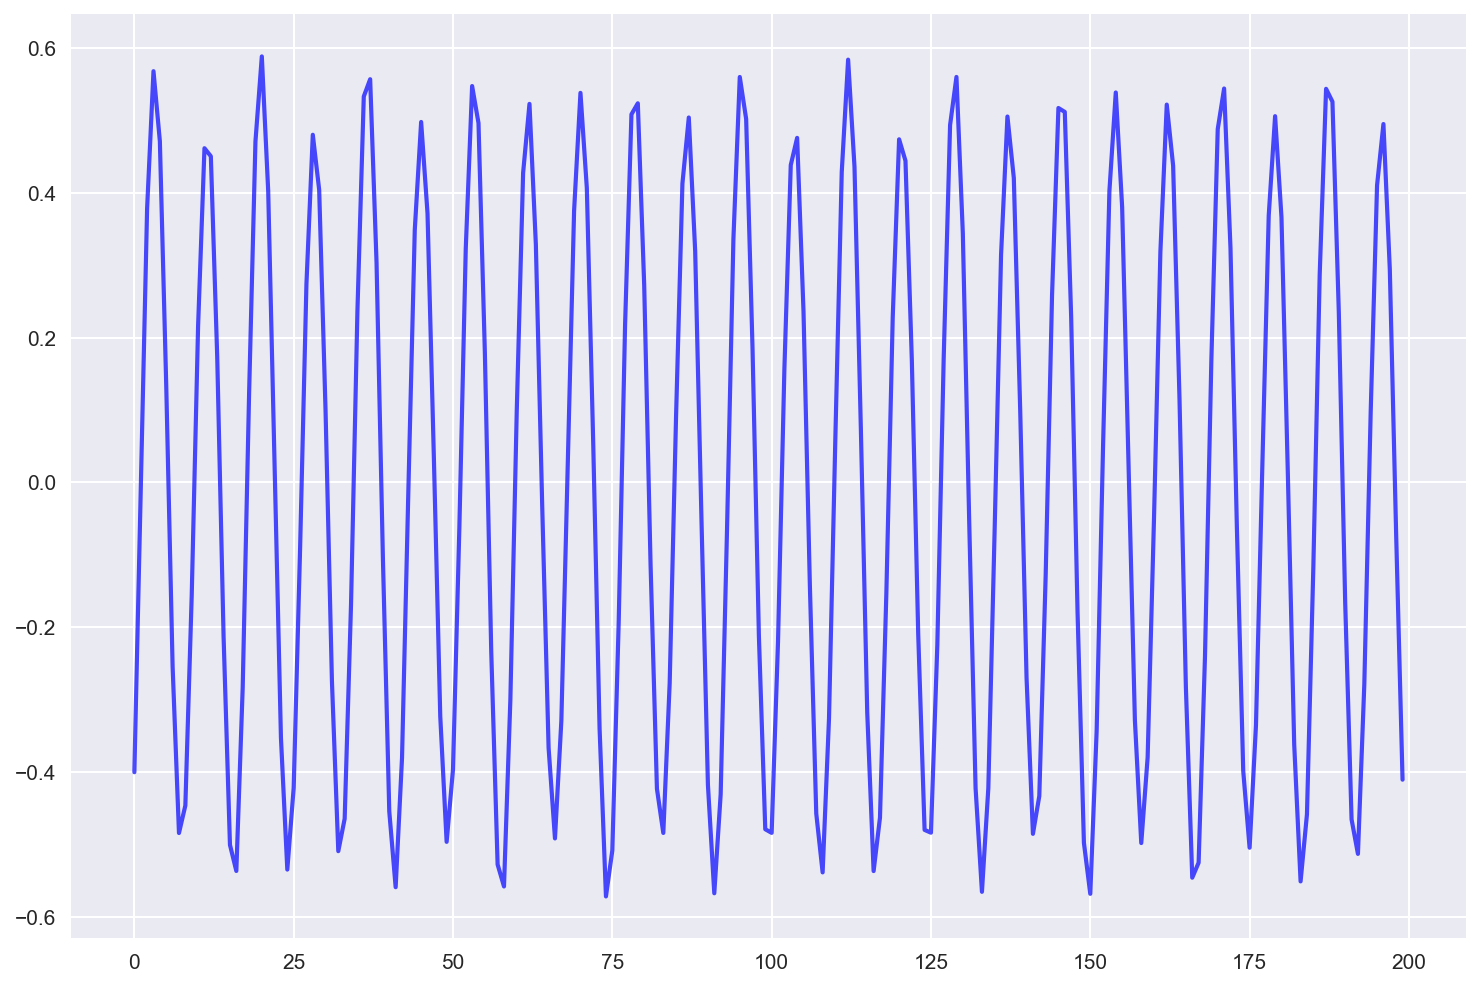

In [ ]:
# Concatenate results for visualization
predictions = np.concatenate(all_predictions, axis=0)
targets = np.concatenate(all_targets, axis=0)

# Plot sample predictions
n_samples = min(3, len(predictions))

for i in range(n_samples):
    # Create dummy input (use first part of target)
    input_data = targets[i, :config['data']['window_size']//2, :]
    target_data = targets[i, config['data']['window_size']//2:, :]
    predicted_data = predictions[i]

    fig = visualizer.plot_trajectory_comparison(
        input_data,
        target_data,
        predicted_data,
        title=f'Sample {i+1} - Prediction vs Ground Truth'
    )
    plt.show()

# fig = visualizer.plot_trajectory_comparison(
#     input_data=features,
#     target_data=targets,
#     predicted_data=targets,  # Using targets as "prediction" for visualization
#     feature_names=['Position', 'Velocity'],
#     title='Sample Vibration Trajectory'
# )

# Plot amplitude analysis if available
if all_amplitudes_pred and all_amplitudes_true:
    amplitudes_pred = np.concatenate(all_amplitudes_pred, axis=0)
    amplitudes_true = np.concatenate(all_amplitudes_true, axis=0)

    fig = visualizer.plot_amplitude_analysis(
        amplitudes_pred.flatten(),
        amplitudes_true.flatten(),
        title='Amplitude Prediction Analysis'
    )
    plt.show()

## 11. Attention Analysis (if available)

In [ ]:
# Get attention weights for a sample
sample_batch = next(iter(test_loader))
sample_batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
               for k, v in sample_batch.items()}

with torch.no_grad():
    # Get attention weights
    attention_weights = model.get_attention_weights(
        sample_batch['features'][:1],  # First sample only
        sample_batch['parameters'][:1]
    )

if attention_weights.numel() > 0:
    # Plot attention weights
    fig = visualizer.plot_attention_weights(
        attention_weights.cpu().numpy(),
        sample_batch['features'][0].cpu().numpy(),
        title='Attention Weights Visualization'
    )
    plt.show()
else:
    print("No attention weights available for this model.")

## 12. Model Performance Summary

In [ ]:
# Create performance summary visualization
fig = visualizer.plot_model_performance_summary(
    evaluation_results,
    title='Model Performance Summary'
)
plt.show()

# Print detailed results
print("\nDetailed Evaluation Results:")
print("=" * 50)

# Group metrics by category
trajectory_metrics = {k: v for k, v in evaluation_results.items()
                     if any(x in k.lower() for x in ['rmse', 'mae', 'r2'])}
amplitude_metrics = {k: v for k, v in evaluation_results.items()
                    if 'amplitude' in k.lower()}
bifurcation_metrics = {k: v for k, v in evaluation_results.items()
                      if 'bifurcation' in k.lower()}

if trajectory_metrics:
    print("\nTrajectory Metrics:")
    for key, value in trajectory_metrics.items():
        print(f"  {key}: {value:.6f}")

if amplitude_metrics:
    print("\nAmplitude Metrics:")
    for key, value in amplitude_metrics.items():
        print(f"  {key}: {value:.6f}")

if bifurcation_metrics:
    print("\nBifurcation Detection Metrics:")
    for key, value in bifurcation_metrics.items():
        print(f"  {key}: {value:.6f}")

print("\n" + "=" * 50)
print("Demo completed successfully!")
print("\nFor full training, use the command line interface:")
print("python main.py --mode train --config config/base_config.yaml --model-config config/lstm_config.yaml")